In [17]:
# Import basic packages
import os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score, f1_score

# Import classification models
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier

from imblearn.over_sampling import SMOTE

import joblib


In [18]:
# Define model constructor
def BuildModel(modelKey):
    models = {
        'svm': SVC(probability=True, kernel='rbf', C=1.0, gamma='scale', random_state=0),
        'rf': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=0),
        'mlp': MLPClassifier(hidden_layer_sizes=(64,), alpha=1e-3, max_iter=5000, random_state=0),
        'logistic': LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=0),
        'nb': GaussianNB(),
        'dt': DecisionTreeClassifier(max_depth=6, random_state=0),
        'knn': KNeighborsClassifier(n_neighbors=5)
    }
    return models[modelKey]

In [19]:
# Preprocessing: remove outliers using IQR method
def Preprocess(rawDataset, outlier_threshold=1):
    features = list(rawDataset.columns[:-1])
    outlier_indices = []

    for feature in features:
        Q1 = np.percentile(rawDataset[feature], 25)
        Q3 = np.percentile(rawDataset[feature], 75)
        IQR = Q3 - Q1
        step = 1.5 * IQR
        outlier_indices.extend(rawDataset[(rawDataset[feature] < Q1 - step) | (rawDataset[feature] > Q3 + step)].index)

    outlier_indices = [idx for idx, count in Counter(outlier_indices).items() if count > outlier_threshold]
    rawDataset = rawDataset.drop(index=outlier_indices).reset_index(drop=True)

    dataset = rawDataset.iloc[:, :-1].values  # Features
    label = rawDataset.iloc[:, -1].values     # Labels
    return dataset, label

In [20]:
def TrainAndEvaluate(dataset, label, model_keys, K=10, scaler_type='minMax'):
    os.makedirs('model', exist_ok=True)

    metrics = {
        'precision': [], 'recall': [], 'auc': [], 'aupr': [], 'f1': []
    }

    skf = StratifiedKFold(n_splits=K)
    smote = SMOTE(random_state=0)

    estimators = []
    full_X, full_y = None, None

    for k, (train_idx, val_idx) in enumerate(skf.split(dataset, label)):
        X_train, X_val = dataset[train_idx], dataset[val_idx]
        y_train, y_val = label[train_idx], label[val_idx]

        # Scaling
        scaler = MinMaxScaler() if scaler_type == 'minMax' else StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        if k == 0:
            joblib.dump(scaler, f'model/minMax.pkl')
            full_X, full_y = X_train.copy(), y_train.copy()

        # SMOTE should be applied after scaling
        X_train, y_train = smote.fit_resample(X_train, y_train)

        prob_val_all = []

        for modelKey in model_keys:
            model = BuildModel(modelKey)
            model.fit(X_train, y_train)

            if k == 0:
                joblib.dump(model, f'model/{modelKey}.pkl')
                estimators.append((modelKey, model))

            prob_val_all.append(model.predict_proba(X_val)[:, 1])

        # Soft Voting Fusion
        if len(model_keys) > 1:
            prob_val_all = np.array(prob_val_all)
            y_score_val = np.mean(prob_val_all, axis=0)
            y_pred_val = (y_score_val >= 0.5).astype(int)
        else:
            y_score_val = prob_val_all[0]
            y_pred_val = (y_score_val >= 0.5).astype(int)

        # Metrics
        metrics['precision'].append(precision_score(y_val, y_pred_val))
        metrics['recall'].append(recall_score(y_val, y_pred_val))
        metrics['auc'].append(roc_auc_score(y_val, y_score_val))
        metrics['aupr'].append(average_precision_score(y_val, y_score_val))
        metrics['f1'].append(f1_score(y_val, y_pred_val))

        print(f"\nFold {k}:")
        print(f"Precision: {metrics['precision'][-1]:.4f}, Recall: {metrics['recall'][-1]:.4f}, "
              f"AUC: {metrics['auc'][-1]:.4f}, AUPR: {metrics['aupr'][-1]:.4f}, F1: {metrics['f1'][-1]:.4f}")

    if len(model_keys) > 1:
        combiner = LogisticRegression(random_state=0)
        stacking = StackingClassifier(estimators=estimators, final_estimator=combiner, passthrough=False)
        stacking.fit(full_X, full_y)
        joblib.dump(stacking, "model/combiner.pkl")

    # Summary
    print("\n========== Average over all folds ==========")
    for key in metrics:
        print(f"Mean {key}: {np.mean(metrics[key]):.4f}")

    # Return results as DataFrame
    df_metrics = pd.DataFrame(metrics)
    df_metrics.index.name = "Fold"
    return df_metrics

In [21]:
# Load dataset
raw_data = pd.read_csv("data/diabetes.csv")  # Make sure this file exists in your working directory
selected_features = ['Pregnancies', 'Glucose', 'BMI', 'Age', 'Outcome']
selected_data = raw_data[selected_features]
# Clean and prepare
dataset, label = Preprocess(selected_data)

model_list = ['svm', 'rf', 'mlp', 'logistic', 'nb', 'dt', 'knn']

# Run training (you can try different combinations)
TrainAndEvaluate(dataset, label, model_keys=model_list, K=10, scaler_type='minMax')


Fold 0:
Precision: 0.5405, Recall: 0.7407, AUC: 0.8222, AUPR: 0.7472, F1: 0.6250

Fold 1:
Precision: 0.6129, Recall: 0.7037, AUC: 0.8341, AUPR: 0.7908, F1: 0.6552

Fold 2:
Precision: 0.6053, Recall: 0.8519, AUC: 0.8422, AUPR: 0.7123, F1: 0.7077

Fold 3:
Precision: 0.5152, Recall: 0.6296, AUC: 0.7222, AUPR: 0.5759, F1: 0.5667

Fold 4:
Precision: 0.6000, Recall: 0.5556, AUC: 0.8311, AUPR: 0.7135, F1: 0.5769

Fold 5:
Precision: 0.6552, Recall: 0.7037, AUC: 0.8667, AUPR: 0.8040, F1: 0.6786

Fold 6:
Precision: 0.7037, Recall: 0.7037, AUC: 0.8444, AUPR: 0.7119, F1: 0.7037

Fold 7:
Precision: 0.6970, Recall: 0.8519, AUC: 0.8798, AUPR: 0.8102, F1: 0.7667

Fold 8:
Precision: 0.6774, Recall: 0.8077, AUC: 0.8323, AUPR: 0.6229, F1: 0.7368

Fold 9:
Precision: 0.7037, Recall: 0.7308, AUC: 0.8646, AUPR: 0.8228, F1: 0.7170

========== Average over all folds ==========
Mean precision: 0.6311
Mean recall: 0.7279
Mean auc: 0.8340
Mean aupr: 0.7312
Mean f1: 0.6734


,precision,recall,auc,aupr,f1
Fold,,,,,
0,0.540541,0.740741,0.822222,0.747200,0.625000
1,0.612903,0.703704,0.834074,0.790805,0.655172
2,0.605263,0.851852,0.842222,0.712311,0.707692
3,0.515152,0.629630,0.722222,0.575892,0.566667
4,0.600000,0.555556,0.831111,0.713461,0.576923
5,0.655172,0.703704,0.866667,0.804017,0.678571
6,0.703704,0.703704,0.844444,0.711861,0.703704
7,0.696970,0.851852,0.879819,0.810197,0.766667
8,0.677419,0.807692,0.832308,0.622941,0.736842



Fold 0:
Precision: 0.5526, Recall: 0.7778, AUC: 0.7861, AUPR: 0.6090, F1: 0.6462

Fold 1:
Precision: 0.5968, Recall: 0.6852, AUC: 0.7419, AUPR: 0.5879, F1: 0.6379

Fold 2:
Precision: 0.6143, Recall: 0.7963, AUC: 0.8294, AUPR: 0.6808, F1: 0.6935

Fold 3:
Precision: 0.6271, Recall: 0.6981, AUC: 0.7931, AUPR: 0.6343, F1: 0.6607

Fold 4:
Precision: 0.5362, Recall: 0.6981, AUC: 0.7475, AUPR: 0.5867, F1: 0.6066

========== Average over all folds ==========
Mean precision: 0.5854
Mean recall: 0.7311
Mean auc: 0.7796
Mean aupr: 0.6197
Mean f1: 0.6490

Fold 0:
Precision: 0.5526, Recall: 0.7778, AUC: 0.7861, AUPR: 0.6090, F1: 0.6462

Fold 1:
Precision: 0.5968, Recall: 0.6852, AUC: 0.7419, AUPR: 0.5879, F1: 0.6379

Fold 2:
Precision: 0.6143, Recall: 0.7963, AUC: 0.8294, AUPR: 0.6808, F1: 0.6935

Fold 3:
Precision: 0.6271, Recall: 0.6981, AUC: 0.7931, AUPR: 0.6343, F1: 0.6607

Fold 4:
Precision: 0.5362, Recall: 0.6981, AUC: 0.7475, AUPR: 0.5867, F1: 0.6066

========== Average over all folds =====

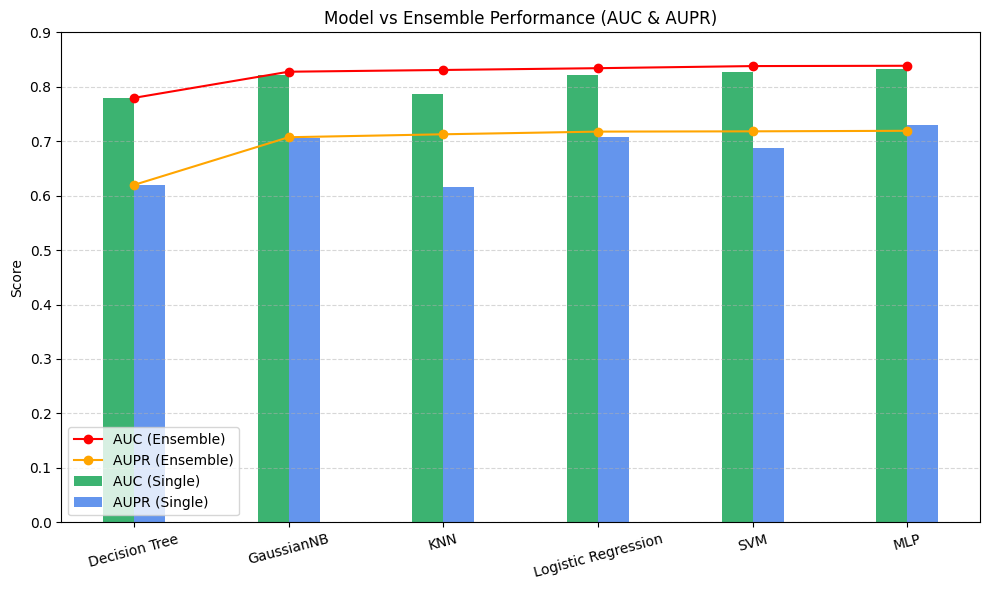

In [10]:
# Plotting the results for report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
model_list = ['dt', 'nb', 'knn', 'logistic', 'svm', 'mlp']
model_names = ['Decision Tree', 'GaussianNB', 'KNN', 'Logistic Regression', 'SVM', 'MLP']

auc_single, aupr_single = [], []
auc_ensemble, aupr_ensemble = [], []

raw_data = pd.read_csv("data/diabetes.csv")
selected_features = ['Pregnancies', 'Glucose', 'BMI', 'Age', 'Outcome']
selected_data = raw_data[selected_features]
dataset, label = Preprocess(selected_data)

for i in range(1, len(model_list) + 1):
    current_keys = model_list[:i]

    df_single = TrainAndEvaluate(dataset, label, m odel_keys=[current_keys[-1]], K=5)
    auc_single.append(df_single['auc'].mean())
    aupr_single.append(df_single['aupr'].mean())

    df_ens = TrainAndEvaluate(dataset, label, model_keys=current_keys, K=5)
    auc_ensemble.append(df_ens['auc'].mean())
    aupr_ensemble.append(df_ens['aupr'].mean())

x = np.arange(len(model_list))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width/2, auc_single, width, label='AUC (Single)', color='mediumseagreen')
ax.bar(x + width/2, aupr_single, width, label='AUPR (Single)', color='cornflowerblue')

ax.plot(x, auc_ensemble, marker='o', label='AUC (Ensemble)', color='red')
ax.plot(x, aupr_ensemble, marker='o', label='AUPR (Ensemble)', color='orange')

ax.set_title('Model vs Ensemble Performance (AUC & AUPR)')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0.0, 0.9)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
